In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler
import numpy as np
import joblib
import matplotlib.pyplot as plt

R_CATHODE = 46.29e-3 / 2   # m  — cathode sphere radius
R_WALL    = 280e-3   / 2   # m  — chamber wall radius

radii = np.linspace(R_CATHODE, R_WALL, 400)  # 400 radial points from cathode to wall

class PlasmaMLP(nn.Module):
    '''
    input: radius, Power, Voltage, Current,Pressure , rat1, rat2, rat3, rat4, rat5  (10 features)
    output: ne, Te (2 features)
    '''
    def __init__(self, input_size=6, hidden_size=128, output_size=2):#change to 10 when adding back power, pressure
        super(PlasmaMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_size, hidden_size // 2),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(hidden_size // 2, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size // 2),
            nn.ReLU(),
            nn.Linear(hidden_size // 2, output_size)
        )

    def forward(self, x):
        return self.network(x)
    
def train_plasma_model_pt(model, X_train_tensor, y_train_tensor, epochs=100, batch_size=32):
    dataset = TensorDataset(X_train_tensor, y_train_tensor)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)
    optimizer = optim.Adam(model.parameters(), lr=0.001)
    criterion = nn.MSELoss()
    
    loss_history = [] # Store losses here

    model.train()
    for epoch in range(epochs):
        epoch_loss = 0
        for batch_x, batch_y in loader:
            optimizer.zero_grad()
            outputs = model(batch_x)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item()
        loss_history.append(epoch_loss / len(loader))
        
    return model, loss_history


In [2]:
import pandas as pd
import numpy as np
import json

def json_to_dataframe(json_file_path):
    with open(json_file_path, 'r') as f:
        data = json.load(f)
    
    rows = []
    
    for run_id, content in data.items():
        # Extract scalar metadata
        current = content['Current']
        voltage = content['Voltage']
        pressure = content['Pressure']
        ratios = content['Peak_Ratios']
        temps = content['Electron_Temperatures']
        dens = content['Electron_Densities']
        
        # Create an index/radius for the spatial profile
        # If your data is 100 points, create a range from 0 to 99 
        # (or define your actual radius values here)
        
        for i, (temp,dens) in enumerate(zip(temps,dens)):
            rows.append({
                'run_id': run_id,
                'radius': radii[i],
                'current': current,
                'voltage': voltage,
                'power': voltage * current,  # Calculate power
                'pressure': pressure,
                # Expand ratios into separate columns
                'rat1': ratios[0] if len(ratios) > 0 else np.nan,
                'rat2': ratios[1] if len(ratios) > 1 else np.nan,
                'rat3': ratios[2] if len(ratios) > 2 else np.nan,
                'rat4': ratios[3] if len(ratios) > 3 else np.nan,
                'rat5': ratios[4] if len(ratios) > 4 else np.nan,
                'te': temp,
                'ne':dens
            })
            
    return pd.DataFrame(rows)

# Load and process
df_plasma = json_to_dataframe('training_data.json')

# Quick clean-up: Remove NaNs if necessary
df_plasma = df_plasma.dropna()

print(df_plasma.head())
print(len(df_plasma))

  run_id    radius  current  voltage   power  pressure      rat1      rat2  \
0      0  0.023145     60.0     38.0  2280.0      51.5  1.504546  2.256411   
1      0  0.023438     60.0     38.0  2280.0      51.5  1.504546  2.256411   
2      0  0.023731     60.0     38.0  2280.0      51.5  1.504546  2.256411   
3      0  0.024024     60.0     38.0  2280.0      51.5  1.504546  2.256411   
4      0  0.024316     60.0     38.0  2280.0      51.5  1.504546  2.256411   

       rat3      rat4      rat5        te            ne  
0  1.063636  1.646767  0.396006  1.583085  1.576645e+17  
1  1.063636  1.646767  0.396006  1.516075  1.488242e+17  
2  1.063636  1.646767  0.396006  1.412786  1.405609e+17  
3  1.063636  1.646767  0.396006  1.354909  1.329036e+17  
4  1.063636  1.646767  0.396006  1.342445  1.257891e+17  
17600


# SKIP the next block if you just want to load the previous model

In [5]:
# Train new model (SKIP if you just want to load the existing one)


from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

def evaluate_plasma_model(df, features, targets, model_class):
    X = df[features].values
    
    y_ne = df[targets[0]].values.reshape(-1, 1)
    y_te = df[targets[1]].values.reshape(-1, 1)
    y = np.hstack([y_ne, y_te])

    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

    # 2. Scale
    scaler_x = StandardScaler().fit(X_train)
    scaler_y = StandardScaler().fit(y_train)

    X_train_t = torch.tensor(scaler_x.transform(X_train), dtype=torch.float32)
    y_train_t = torch.tensor(scaler_y.transform(y_train), dtype=torch.float32)
    
    X_test_t = torch.tensor(scaler_x.transform(X_test), dtype=torch.float32)
    y_test_t = torch.tensor(scaler_y.transform(y_test), dtype=torch.float32)

    # 3. Initialize and Train
    model = model_class() # Instantiate the PlasmaMLP class
    model, loss_history = train_plasma_model_pt(model, X_train_t, y_train_t)

    # Evaluate
    model.eval() 
    with torch.no_grad():
        preds = model(X_test_t)
        
        # Split the tensors by column (0 for ne, 1 for te)
        pred_ne = preds[:, 0]
        true_ne = y_test_t[:, 0]
        
        pred_te = preds[:, 1]
        true_te = y_test_t[:, 1]

        # Calculate individual MSEs
        mse_ne = nn.functional.mse_loss(pred_ne, true_ne).item()
        mse_te = nn.functional.mse_loss(pred_te, true_te).item()
        
        # Total MSE (for context)
        mse_total = nn.functional.mse_loss(preds, y_test_t).item()
    
    print(f"Total MSE: {mse_total:.4f}")
    print(f"Density (ne) MSE: {mse_ne:.4f}")
    print(f"Temperature (te) MSE: {mse_te:.4f}")

    plt.plot(loss_history)
    plt.title("Training Loss Convergence")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.show()
    
    return mse_ne, mse_te, model, scaler_x, scaler_y



Total MSE: 0.0335
Density (ne) MSE: 0.0474
Temperature (te) MSE: 0.0197


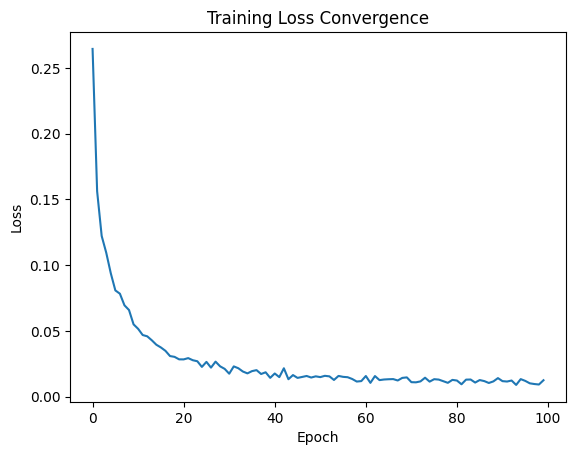

In [12]:
# --- Execution ---
features = ['radius', 'power', 'voltage', 'current', 'pressure', 'rat1', 'rat2', 'rat3', 'rat4', 'rat5']
features = ['radius','rat1', 'rat2', 'rat3', 'rat4', 'rat5']

targets = ['ne', 'te']

mse_ne,mse_te, trained_model, scaler_x, scaler_y = evaluate_plasma_model(df_plasma, features, targets, PlasmaMLP)


In [19]:
#load ratio model from previous training

trained_model = PlasmaMLP() 

trained_model.load_state_dict(torch.load('plasma_model_ratonly.pth'))
trained_model.eval() 

scaler_x = joblib.load('scaler_x_ratonly.pkl')
scaler_y = joblib.load('scaler_y_ratonly.pkl')

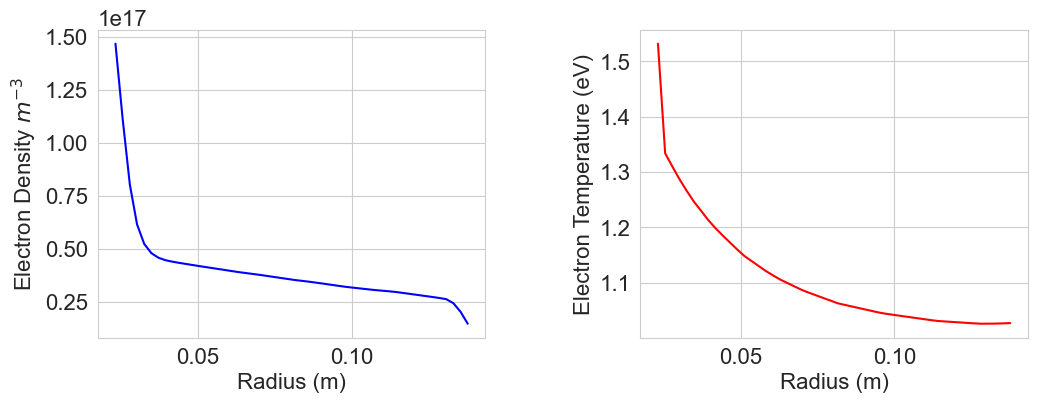

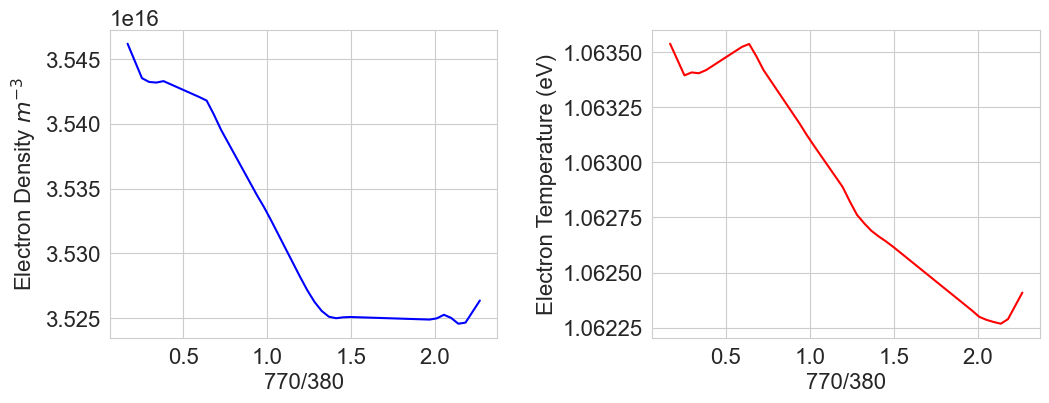

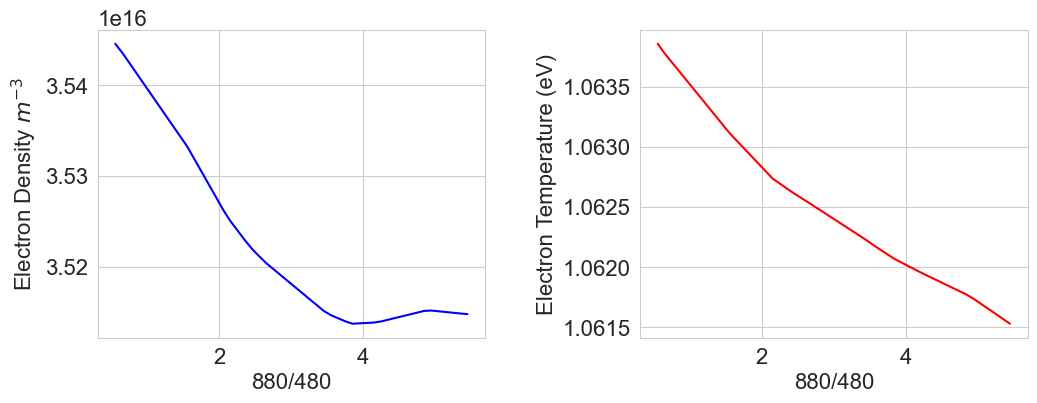

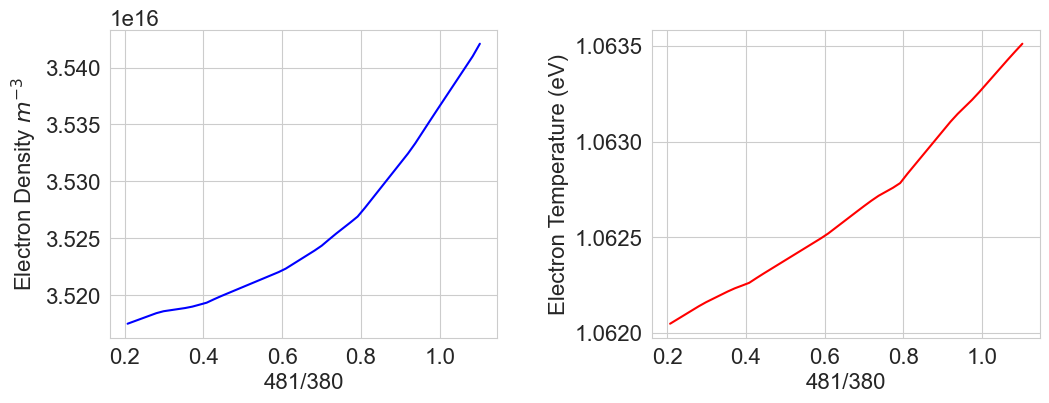

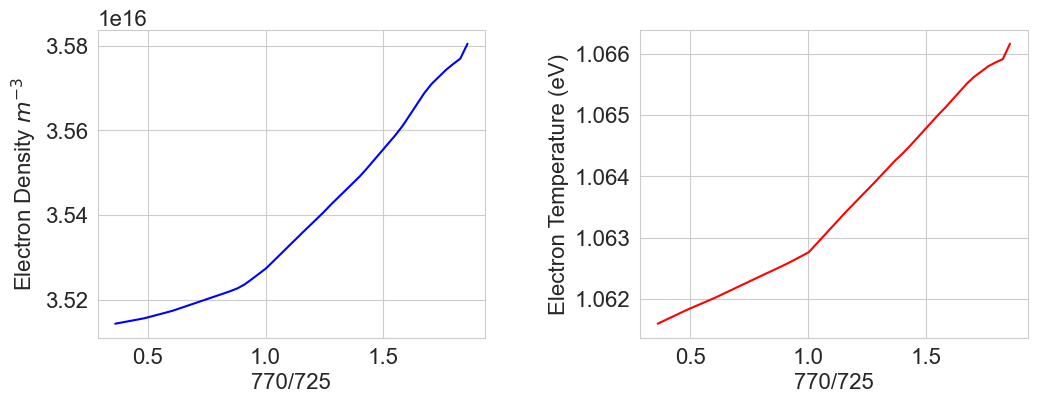

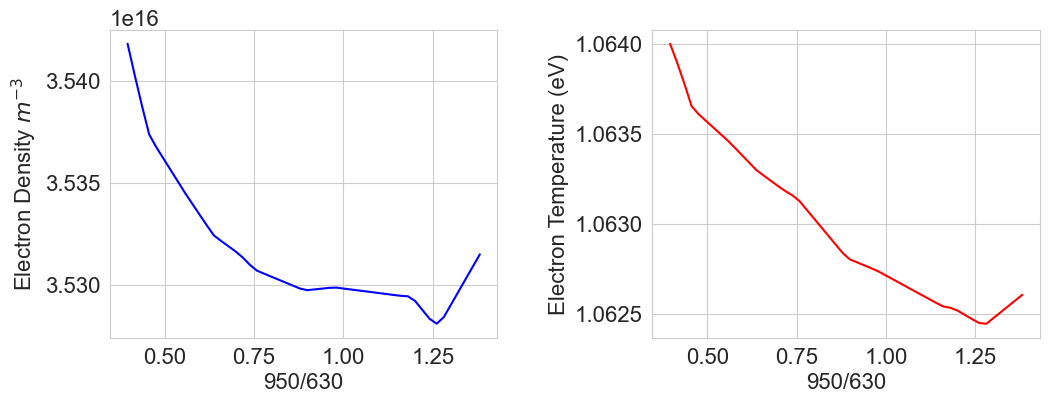

In [43]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")


feature_fancy = ['Radius (m)','770/380', '880/480', '481/380', '770/725', '950/630']

def plot_response_curves(model, scaler_x, scaler_y, baseline_df, features):
    model.eval()
    baseline_values = baseline_df[features].median().values
    steps = 50
    
    for i, feature in enumerate(features):
        f_min = baseline_df[feature].min()
        f_max = baseline_df[feature].max()
        sweep_values = [f_min + (f_max - f_min) * (step / steps) for step in range(steps)]
        
        # Prepare input (PyTorch List approach)
        input_list = [list(baseline_values) for _ in range(steps)]
        for idx in range(steps):
            input_list[idx][i] = sweep_values[idx]
            
        # Scale (using your scaler, we need to pass a numpy-like array but 
        # since we are desperate, we can use the scaler's transform on the list directly)
        input_scaled = scaler_x.transform(input_list) 
        input_tensor = torch.tensor(input_scaled, dtype=torch.float32)
        
        with torch.no_grad():
            output_scaled = model(input_tensor).detach().cpu().tolist()
            

        output_physical = scaler_y.inverse_transform(output_scaled)
        
        # Plotting using standard Python lists
        ne_pred = [row[0] for row in output_physical]
        te_pred = [row[1] for row in output_physical]
        
        fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
        ax1.plot(sweep_values, ne_pred, color='blue')
        ax1.set_xlabel(feature_fancy[i])
        ax1.set_ylabel('Electron Density $m^{-3}$')
        ax2.plot(sweep_values, te_pred, color='red')
        ax2.set_xlabel(feature_fancy[i])
        ax2.set_ylabel('Electron Temperature (eV)')
        plt.subplots_adjust(wspace=0.4)
        plt.show()

plot_response_curves(trained_model, scaler_x, scaler_y, df_plasma, features)

In [44]:
import joblib

torch.save(trained_model.state_dict(), 'plasma_model.pth')
# Save the scaler
joblib.dump(scaler_x, 'scaler_x.pkl')
joblib.dump(scaler_y, 'scaler_y.pkl')

['scaler_y.pkl']

Starting Ablation on line ratios. 'radius' will remain in all models.
Model without rat1: MSE = 0.018534
Model without rat2: MSE = 0.016228
Model without rat3: MSE = 0.013564
Model without rat4: MSE = 0.014162
Model without rat5: MSE = 0.022262


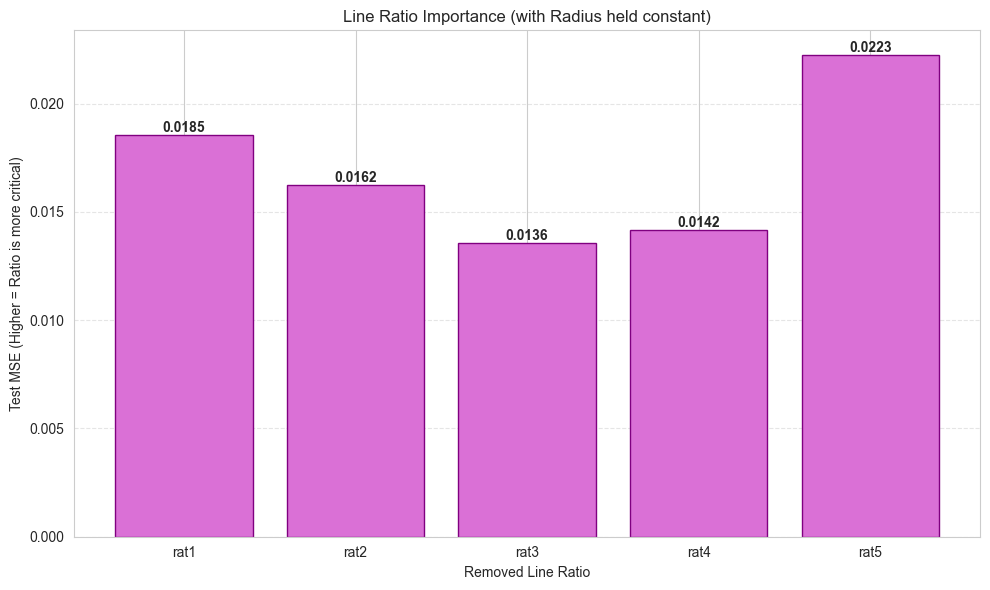

In [ ]:


feature_fancy = ['radius (m)','770/380', '880/480', '481/380', '770/725', '950/630']


def run_ratio_ablation(df, features, targets, model_class):
    mse_results = []
    # We keep the first feature (radius) and only ablate the rest
    features_to_ablate = features[1:] 
    
    print(f"Starting Ablation on line ratios. 'radius' will remain in all models.")
    
    for current_var in features_to_ablate:
        # Create a subset that keeps radius + all other rats EXCEPT the current_var
        current_subset = [f for f in features if f != current_var]
        
        # Data Prep
        X = df[current_subset].values
        y = df[targets].values
        X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
        
        scaler_x = StandardScaler().fit(X_train)
        scaler_y = StandardScaler().fit(y_train)
        
        X_train_t = torch.tensor(scaler_x.transform(X_train), dtype=torch.float32)
        y_train_t = torch.tensor(scaler_y.transform(y_train), dtype=torch.float32)
        X_test_t  = torch.tensor(scaler_x.transform(X_test), dtype=torch.float32)
        y_test_t  = torch.tensor(scaler_y.transform(y_test), dtype=torch.float32)
        
        # Train fresh model for this specific combination
        model = model_class(input_size=len(current_subset)) 
        model, _ = train_plasma_model_pt(model, X_train_t, y_train_t, epochs=100)
        
        # Evaluate
        model.eval()
        with torch.no_grad():
            preds = model(X_test_t)
            mse = nn.functional.mse_loss(preds, y_test_t).item()
            
        mse_results.append(mse)
        print(f"Model without {current_var}: MSE = {mse:.6f}")

    # Visualization
    plt.figure(figsize=(10, 6))
    bars = plt.bar(features_to_ablate, mse_results, color='orchid', edgecolor='purple')
    
    plt.ylabel("Test MSE ")
    plt.xlabel("Removed Line Ratio")
    plt.grid(axis='y', linestyle='--', alpha=0.5)
    
    for bar in bars:
        yval = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.4f}', 
                 va='bottom', ha='center', fontweight='bold')

    plt.tight_layout()
    plt.show()

    return pd.DataFrame({'Removed_Ratio': features_to_ablate, 'MSE': mse_results})

# --- Execution ---
# Define the order you want to test
ordered_features = ['radius','rat1', 'rat2', 'rat3', 'rat4', 'rat5']
targets = ['ne', 'te']

incremental_df = run_ratio_ablation(df_plasma, ordered_features, targets, PlasmaMLP)

In [37]:
incremental_df.head()


incremental_df.Removed_Ratio = pd.DataFrame(['770/380', '880/480', '481/380', '770/725', '950/630'])

incremental_df.head()



,Removed_Ratio,MSE
0,770/380,0.018534
1,880/480,0.016228
2,481/380,0.013564
3,770/725,0.014162
4,950/630,0.022262


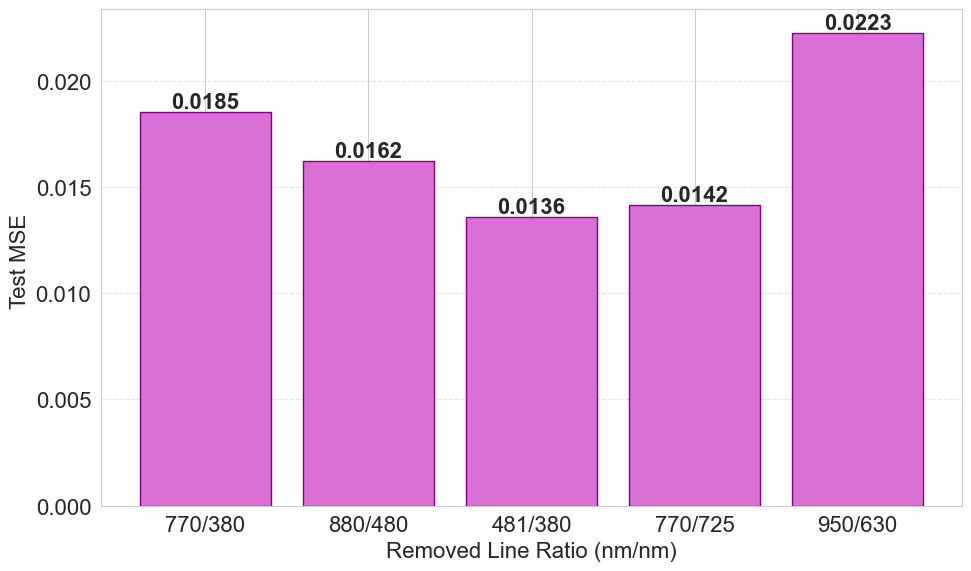

In [39]:
plt.figure(figsize=(10, 6))
plt.rcParams.update({'font.size': 16})
bars = plt.bar(incremental_df.Removed_Ratio, incremental_df.MSE, color='orchid', edgecolor='purple')

plt.ylabel("Test MSE ")
plt.xlabel("Removed Line Ratio (nm/nm)")
plt.grid(axis='y', linestyle='--', alpha=0.5)

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, f'{yval:.4f}', 
                va='bottom', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()